# L02 — The Good and Evil of KV Cache

**Vizuara Inference Engineering Workshop**  
**Instructor:** Dr. Raj  
**Hardware:** NVIDIA H100 80GB HBM3  

This notebook demonstrates:
1. **The autoregressive loop** — naive token-by-token generation (no caching)
2. **KV Cache speedup** — per-token latency benchmark on a 7B model
3. **The dark side** — KV cache memory analysis and the formula
4. **Production inference** — vLLM throughput with batching

---
## 0. Setup

In [1]:
!pip install -q transformers accelerate matplotlib numpy


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu} ({mem:.0f} GB)")
# Disable cuDNN's SDPA path (workaround for a bug with Qwen2 in some torch builds)
torch.backends.cuda.enable_cudnn_sdp(False)


PyTorch: 2.11.0+cu130
CUDA: True
GPU: NVIDIA H100 80GB HBM3 (85 GB)


---
## 1. The Autoregressive Loop — Visualizing the Waste

At every step, the model receives the **entire sequence** and processes all tokens —
but only uses the **last row** of the output to predict the next token.

Watch the input grow with each generated token:

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# We use Qwen2.5-7B — large enough to show real effects on H100
MODEL_NAME = "Qwen/Qwen2.5-7B"

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16).cuda().eval()
print("Model loaded!")

Loading Qwen/Qwen2.5-7B...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded!


In [4]:
prompt = "The next day is bright"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
input_ids = inputs.input_ids

print(f"Prompt: '{prompt}'")
print(f"Initial tokens: {input_ids.shape[1]}\n")
print("Generated: ", end="")

for step in range(30):
    with torch.no_grad():
        outputs = model(input_ids)              # ← Full forward pass on ALL tokens
    logits = outputs.logits
    next_token_logits = logits[:, -1, :]        # ← Only use the LAST row
    next_token_id = next_token_logits.argmax(dim=-1).unsqueeze(-1)
    input_ids = torch.cat([input_ids, next_token_id], dim=-1)  # Append
    print(tokenizer.decode(next_token_id[0]), end="", flush=True)

print(f"\n\nFinal sequence: {input_ids.shape[1]} tokens")
print("\n⚠️  model(input_ids) is called INSIDE the loop.")
print("   At step 30, we pass 35 tokens through the ENTIRE 7B-param model")
print("   just to get logits for the LAST token. Everything else is wasted!")

Prompt: 'The next day is bright'
Initial tokens: 5

Generated: 

 and

 sunny

.

 The

...

 the

 garden

.

 The



Final sequence: 35 tokens

⚠️  model(input_ids) is called INSIDE the loop.
   At step 30, we pass 35 tokens through the ENTIRE 7B-param model
   just to get logits for the LAST token. Everything else is wasted!


---
## 2. KV Cache Speedup — The Real Benchmark

We measure **per-token latency** as the sequence grows. This is the clearest way to see the effect:

- **Without cache:** latency should **increase** with each token (reprocessing everything)
- **With cache:** latency should stay **flat** (only processing the new token)

We use CUDA events for precise GPU-level timing (no Python overhead).

In [5]:
# Create a long prompt to start from a realistic context length
long_text = ("The history of artificial intelligence began in antiquity with myths "
             "and stories of artificial beings endowed with intelligence. ") * 300

N_DECODE_STEPS = 80  # tokens to generate

# We'll benchmark at different starting context lengths
context_lengths = [512, 1024, 2048, 4096]
all_results = {}

for ctx_len in context_lengths:
    inputs = tokenizer(long_text, return_tensors="pt",
                       max_length=ctx_len, truncation=True).to("cuda")
    base_ids = inputs.input_ids
    actual_len = base_ids.shape[1]

    # === WITHOUT KV Cache ===
    ids = base_ids.clone()
    # Warm up
    with torch.no_grad():
        _ = model(ids[:, :100], use_cache=False)
    torch.cuda.synchronize()

    no_cache_times = []
    for step in range(N_DECODE_STEPS):
        se = torch.cuda.Event(enable_timing=True)
        ee = torch.cuda.Event(enable_timing=True)
        se.record()
        with torch.no_grad():
            out = model(ids, use_cache=False)
        ee.record()
        torch.cuda.synchronize()
        no_cache_times.append(se.elapsed_time(ee))
        next_id = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ids = torch.cat([ids, next_id], dim=-1)

    # === WITH KV Cache ===
    ids = base_ids.clone()
    # Prefill
    se = torch.cuda.Event(enable_timing=True)
    ee = torch.cuda.Event(enable_timing=True)
    se.record()
    with torch.no_grad():
        out = model(ids, use_cache=True)
    ee.record()
    torch.cuda.synchronize()
    prefill_ms = se.elapsed_time(ee)

    past = out.past_key_values
    next_id = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    ids = torch.cat([ids, next_id], dim=-1)

    cache_times = []
    for step in range(N_DECODE_STEPS):
        se = torch.cuda.Event(enable_timing=True)
        ee = torch.cuda.Event(enable_timing=True)
        se.record()
        with torch.no_grad():
            out = model(ids[:, -1:], use_cache=True, past_key_values=past)
        ee.record()
        torch.cuda.synchronize()
        cache_times.append(se.elapsed_time(ee))
        past = out.past_key_values
        next_id = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ids = torch.cat([ids, next_id], dim=-1)

    avg_nc = sum(no_cache_times) / len(no_cache_times)
    avg_c = sum(cache_times) / len(cache_times)
    speedup = avg_nc / avg_c

    all_results[ctx_len] = {
        "no_cache_times": no_cache_times,
        "cache_times": cache_times,
        "prefill_ms": prefill_ms,
        "avg_nc": avg_nc,
        "avg_c": avg_c,
        "speedup": speedup,
    }

    print(f"Context {actual_len:>5d}: "
          f"No Cache {avg_nc:>6.1f} ms/tok | "
          f"Cache {avg_c:>5.1f} ms/tok | "
          f"Prefill {prefill_ms:>5.1f} ms | "
          f"Speedup {speedup:.1f}×")

Context   512: No Cache   23.3 ms/tok | Cache  11.6 ms/tok | Prefill  19.6 ms | Speedup 2.0×


Context  1024: No Cache   36.4 ms/tok | Cache  11.6 ms/tok | Prefill  34.1 ms | Speedup 3.1×


Context  2048: No Cache   66.7 ms/tok | Cache  11.6 ms/tok | Prefill  65.9 ms | Speedup 5.7×


Context  4096: No Cache  132.0 ms/tok | Cache  11.7 ms/tok | Prefill 131.9 ms | Speedup 11.3×


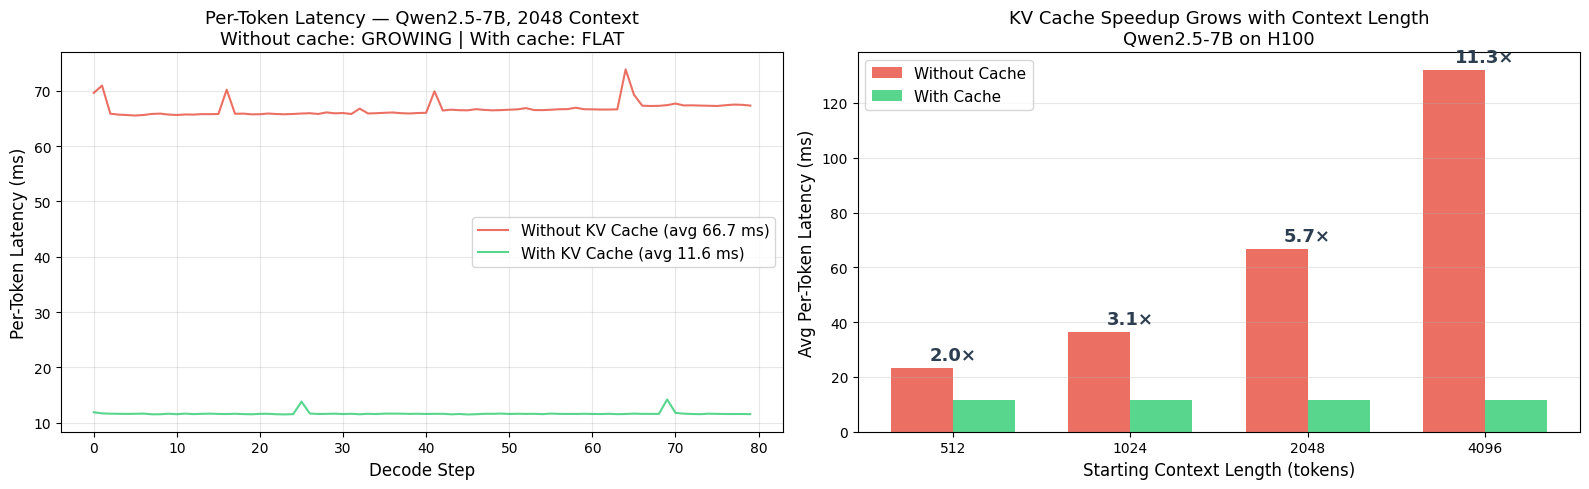


📊 Key insights:
   1. Without cache: latency GROWS because we reprocess everything
   2. With cache: latency stays FLAT — only processes the new token
   3. Speedup scales linearly with context length
   4. At 4096 context: 11.3× speedup!


In [6]:
# ========== PLOT 1: Per-token latency over time (2048 context) ==========
ctx_key = 2048
r = all_results[ctx_key]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: Per-token latency trace
steps = range(len(r["no_cache_times"]))
ax1.plot(steps, r["no_cache_times"], color='#e74c3c', linewidth=1.5,
         alpha=0.8, label=f'Without KV Cache (avg {r["avg_nc"]:.1f} ms)')
ax1.plot(steps, r["cache_times"], color='#2ecc71', linewidth=1.5,
         alpha=0.8, label=f'With KV Cache (avg {r["avg_c"]:.1f} ms)')
ax1.set_xlabel('Decode Step', fontsize=12)
ax1.set_ylabel('Per-Token Latency (ms)', fontsize=12)
ax1.set_title(f'Per-Token Latency — Qwen2.5-7B, {ctx_key} Context\n'
              f'Without cache: GROWING | With cache: FLAT', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Speedup vs context length
ctx_lens = sorted(all_results.keys())
speedups = [all_results[c]["speedup"] for c in ctx_lens]
avg_ncs = [all_results[c]["avg_nc"] for c in ctx_lens]
avg_cs = [all_results[c]["avg_c"] for c in ctx_lens]

x = np.arange(len(ctx_lens))
width = 0.35
bars1 = ax2.bar(x - width/2, avg_ncs, width, label='Without Cache',
                color='#e74c3c', alpha=0.8)
bars2 = ax2.bar(x + width/2, avg_cs, width, label='With Cache',
                color='#2ecc71', alpha=0.8)

# Add speedup labels
for i, (nc, c, s) in enumerate(zip(avg_ncs, avg_cs, speedups)):
    ax2.annotate(f'{s:.1f}×', xy=(i, max(nc, c) + 3),
                ha='center', fontsize=13, fontweight='bold', color='#2c3e50')

ax2.set_xticks(x)
ax2.set_xticklabels([str(c) for c in ctx_lens])
ax2.set_xlabel('Starting Context Length (tokens)', fontsize=12)
ax2.set_ylabel('Avg Per-Token Latency (ms)', fontsize=12)
ax2.set_title('KV Cache Speedup Grows with Context Length\n'
              'Qwen2.5-7B on H100', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('kv_cache_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insights:")
print("   1. Without cache: latency GROWS because we reprocess everything")
print("   2. With cache: latency stays FLAT — only processes the new token")
print("   3. Speedup scales linearly with context length")
print(f"   4. At 4096 context: {all_results[4096]['speedup']:.1f}× speedup!")

---
## 3. The Dark Side — KV Cache Memory Analysis

The KV cache trades **compute** for **memory**. Let's quantify exactly how much memory it consumes.

### The Formula

```
KV Cache Size (bytes) = 2 × layers × batch_size × kv_heads × head_dim × seq_len × bytes_per_param
                        │                         │                               │
                        K and V                   GQA reduces this                2 for fp16
```

In [7]:
def kv_cache_size_gb(layers, kv_heads, head_dim, seq_len,
                     batch_size=1, bytes_per_param=2):
    """Calculate KV cache size in GB."""
    # 2 for K and V matrices
    size_bytes = 2 * layers * batch_size * kv_heads * head_dim * seq_len * bytes_per_param
    return size_bytes / (1024**3)


# Real model specifications
models = {
    "GPT-2 (124M)":          dict(layers=12,  kv_heads=12,  head_dim=64,  seq_len=1024),
    "Llama 3 8B (GQA)":      dict(layers=32,  kv_heads=8,   head_dim=128, seq_len=8192),
    "Qwen2.5-7B (GQA)":      dict(layers=28,  kv_heads=4,   head_dim=128, seq_len=8192),
    "GPT-3 (175B, MHA)":     dict(layers=96,  kv_heads=96,  head_dim=128, seq_len=4096),
    "Llama 3 70B (GQA)":     dict(layers=80,  kv_heads=8,   head_dim=128, seq_len=8192),
    "DeepSeek-V3 (671B)":    dict(layers=61,  kv_heads=128, head_dim=128, seq_len=128000),
}

print(f"{'Model':<25} {'b=1':>10} {'b=32':>10} {'b=128':>12}")
print("─" * 60)
for name, cfg in models.items():
    s1 = kv_cache_size_gb(**cfg, batch_size=1)
    s32 = kv_cache_size_gb(**cfg, batch_size=32)
    s128 = kv_cache_size_gb(**cfg, batch_size=128)
    print(f"{name:<25} {s1:>8.2f} GB {s32:>8.1f} GB {s128:>9.1f} GB")

print("\n⚠️  DeepSeek-V3 at 128K context: 478 GB for a SINGLE sequence!")
print("   This is why DeepSeek invented Multi-Head Latent Attention (MLA).")

Model                            b=1       b=32        b=128
────────────────────────────────────────────────────────────
GPT-2 (124M)                  0.04 GB      1.1 GB       4.5 GB
Llama 3 8B (GQA)              1.00 GB     32.0 GB     128.0 GB
Qwen2.5-7B (GQA)              0.44 GB     14.0 GB      56.0 GB
GPT-3 (175B, MHA)            18.00 GB    576.0 GB    2304.0 GB
Llama 3 70B (GQA)             2.50 GB     80.0 GB     320.0 GB
DeepSeek-V3 (671B)          476.56 GB  15250.0 GB   61000.0 GB

⚠️  DeepSeek-V3 at 128K context: 478 GB for a SINGLE sequence!
   This is why DeepSeek invented Multi-Head Latent Attention (MLA).


### 3.1 — Measuring the KV Cache Live on GPU

Let's inspect the actual KV cache tensors that HuggingFace stores during inference.

In [8]:
# Inspect the KV cache object from our model
long_text = ("The history of artificial intelligence began in antiquity "
             "with myths and stories of artificial beings endowed with intelligence. ") * 500

print("=== KV Cache Structure (Qwen2.5-7B) ===\n")

for ctx_len in [1024, 2048, 4096, 8192]:
    inputs = tokenizer(long_text, return_tensors="pt",
                       max_length=ctx_len, truncation=True).to("cuda")
    torch.cuda.empty_cache()

    with torch.no_grad():
        out = model(inputs.input_ids, use_cache=True)
    past = out.past_key_values

    # Measure total KV cache memory (DynamicCache yields tuples per layer)
    kv_bytes = 0
    n_layers = 0
    for layer_tuple in past:
        n_layers += 1
        for tensor in layer_tuple:
            if tensor is not None and hasattr(tensor, 'nelement'):
                kv_bytes += tensor.nelement() * tensor.element_size()

    actual_seq = inputs.input_ids.shape[1]
    # Formula prediction (Qwen2.5-7B: 28 layers, 4 KV heads, head_dim 128)
    predicted = kv_cache_size_gb(layers=28, kv_heads=4, head_dim=128,
                                 seq_len=actual_seq) * 1024  # in MB

    print(f"Context {actual_seq:>5d}: Measured {kv_bytes/1e6:>6.1f} MB | "
          f"Formula {predicted:>6.1f} MB | "
          f"Layers: {n_layers}")

    if ctx_len == 1024:
        # Show shape of first layer's K tensor
        first_layer = list(past)[0]
        print(f"  K shape: {first_layer[0].shape}  →  (batch, kv_heads, seq_len, head_dim)")

    del out, past
    torch.cuda.empty_cache()

print(f"\n✅ Formula matches live measurement!")
print(f"   KV cache grows linearly with sequence length — no escape.")

=== KV Cache Structure (Qwen2.5-7B) ===

Context  1024: Measured   58.7 MB | Formula   56.0 MB | Layers: 28
  K shape: torch.Size([1, 4, 1024, 128])  →  (batch, kv_heads, seq_len, head_dim)
Context  2048: Measured  117.4 MB | Formula  112.0 MB | Layers: 28


Context  4096: Measured  234.9 MB | Formula  224.0 MB | Layers: 28
Context  8192: Measured  469.8 MB | Formula  448.0 MB | Layers: 28



✅ Formula matches live measurement!
   KV cache grows linearly with sequence length — no escape.


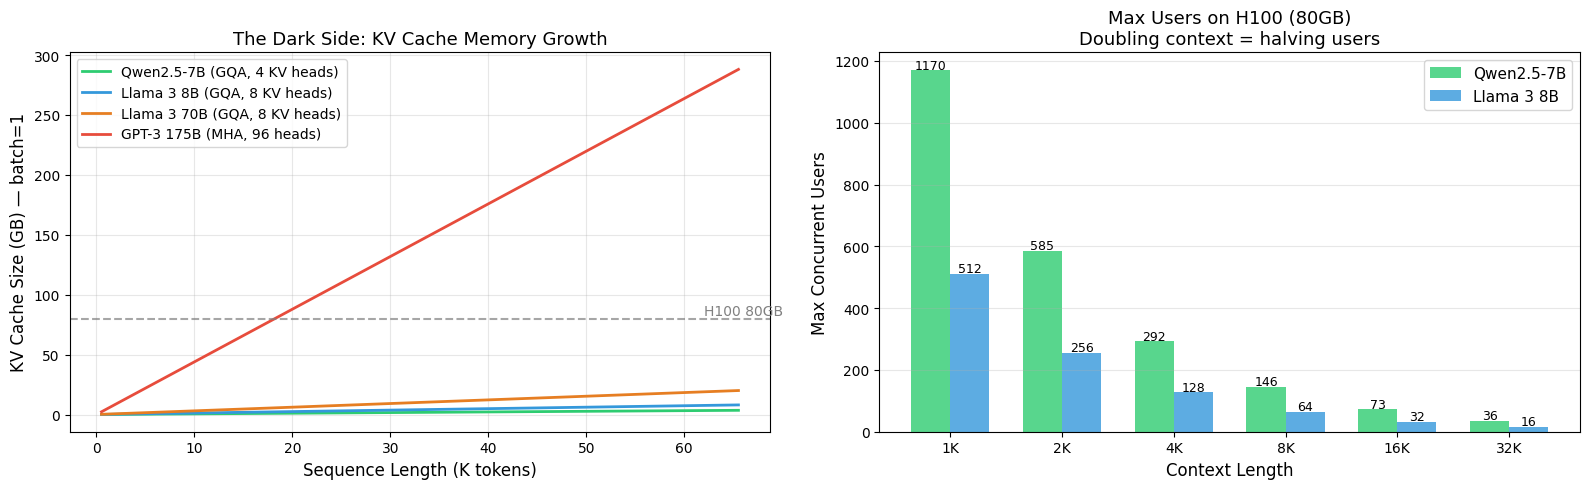


💡 Doubling context length HALVES your max concurrent users.
   This is why API providers charge more for larger context windows.
   The hardware cost is dominated by KV cache memory, not compute.


In [9]:
# ========== PLOT 2: KV cache size vs context length ==========
seq_lengths = np.arange(512, 65537, 512)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: KV cache growth per model
plot_models = {
    "Qwen2.5-7B (GQA, 4 KV heads)": dict(layers=28, kv_heads=4, head_dim=128),
    "Llama 3 8B (GQA, 8 KV heads)":  dict(layers=32, kv_heads=8, head_dim=128),
    "Llama 3 70B (GQA, 8 KV heads)": dict(layers=80, kv_heads=8, head_dim=128),
    "GPT-3 175B (MHA, 96 heads)":     dict(layers=96, kv_heads=96, head_dim=128),
}
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

for (name, cfg), color in zip(plot_models.items(), colors):
    sizes = [kv_cache_size_gb(**cfg, seq_len=s) for s in seq_lengths]
    ax1.plot(seq_lengths / 1000, sizes, linewidth=2, label=name, color=color)

ax1.axhline(y=80, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.text(62, 83, 'H100 80GB', fontsize=10, color='gray')
ax1.set_xlabel('Sequence Length (K tokens)', fontsize=12)
ax1.set_ylabel('KV Cache Size (GB) — batch=1', fontsize=12)
ax1.set_title('The Dark Side: KV Cache Memory Growth', fontsize=13)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)

# Right: Max concurrent users on H100
model_mem_gb = 14  # Qwen2.5-7B fp16
overhead_gb = 2
available = 80 - model_mem_gb - overhead_gb

ctx_options = [1024, 2048, 4096, 8192, 16384, 32768]
users_qwen = []
users_llama8b = []
for ctx in ctx_options:
    kv_qwen = kv_cache_size_gb(layers=28, kv_heads=4, head_dim=128, seq_len=ctx)
    kv_llama = kv_cache_size_gb(layers=32, kv_heads=8, head_dim=128, seq_len=ctx)
    users_qwen.append(int(available / kv_qwen) if kv_qwen > 0 else 0)
    users_llama8b.append(int(available / kv_llama) if kv_llama > 0 else 0)

x = np.arange(len(ctx_options))
width = 0.35
ax2.bar(x - width/2, users_qwen, width, label='Qwen2.5-7B', color='#2ecc71', alpha=0.8)
ax2.bar(x + width/2, users_llama8b, width, label='Llama 3 8B', color='#3498db', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{c//1024}K' for c in ctx_options])
ax2.set_xlabel('Context Length', fontsize=12)
ax2.set_ylabel('Max Concurrent Users', fontsize=12)
ax2.set_title('Max Users on H100 (80GB)\nDoubling context = halving users', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
for i, (q, l) in enumerate(zip(users_qwen, users_llama8b)):
    ax2.text(i - width/2, q + 5, str(q), ha='center', fontsize=9)
    ax2.text(i + width/2, l + 5, str(l), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('kv_cache_dark_side.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Doubling context length HALVES your max concurrent users.")
print("   This is why API providers charge more for larger context windows.")
print("   The hardware cost is dominated by KV cache memory, not compute.")

### 3.2 — The Memory Budget on H100

On a real GPU, memory is shared between:
- **Model weights** (fixed)
- **KV cache** (grows with context × batch)
- **Activations** (temporary)

The KV cache determines how many users you can serve simultaneously.

In [10]:
def analyze_serving(gpu_mem_gb, model_name, model_mem_gb, layers, kv_heads,
                    head_dim, overhead_gb=2.0):
    """Analyze serving capacity for a model on a GPU."""
    available = gpu_mem_gb - model_mem_gb - overhead_gb
    print(f"\n{'='*60}")
    print(f"{model_name} on {gpu_mem_gb}GB GPU")
    print(f"  Model weights: {model_mem_gb} GB")
    print(f"  Overhead:      {overhead_gb} GB")
    print(f"  Available:     {available:.0f} GB for KV cache")
    print(f"{'─'*60}")
    print(f"  {'Context':<10} {'KV/user':>10} {'Max Users':>12} {'Total KV':>10}")
    print(f"{'─'*60}")
    for ctx in [2048, 4096, 8192, 32768, 131072]:
        kv_per_user = kv_cache_size_gb(layers, kv_heads, head_dim, ctx)
        max_users = int(available / kv_per_user) if kv_per_user > 0 else 0
        total_kv = kv_per_user * max_users
        print(f"  {ctx:<10d} {kv_per_user*1000:>8.0f} MB {max_users:>10d}   {total_kv:>8.1f} GB")


analyze_serving(80, "Qwen2.5-7B (fp16)", 14,
                layers=28, kv_heads=4, head_dim=128)

analyze_serving(80, "Llama 3 8B (fp16)", 16,
                layers=32, kv_heads=8, head_dim=128)

analyze_serving(80, "Llama 3 70B (fp16, TP=4, per-GPU)", 35,
                layers=80, kv_heads=8, head_dim=128)

print("\n\n🔑 KEY TAKEAWAY:")
print("   The KV cache — not model weights — is the #1 bottleneck for serving.")
print("   This is why the ENTIRE next lecture (L03) is about reducing it.")


Qwen2.5-7B (fp16) on 80GB GPU
  Model weights: 14 GB
  Overhead:      2.0 GB
  Available:     64 GB for KV cache
────────────────────────────────────────────────────────────
  Context       KV/user    Max Users   Total KV
────────────────────────────────────────────────────────────
  2048            109 MB        585       64.0 GB
  4096            219 MB        292       63.9 GB
  8192            438 MB        146       63.9 GB
  32768          1750 MB         36       63.0 GB
  131072         7000 MB          9       63.0 GB

Llama 3 8B (fp16) on 80GB GPU
  Model weights: 16 GB
  Overhead:      2.0 GB
  Available:     62 GB for KV cache
────────────────────────────────────────────────────────────
  Context       KV/user    Max Users   Total KV
────────────────────────────────────────────────────────────
  2048            250 MB        248       62.0 GB
  4096            500 MB        124       62.0 GB
  8192           1000 MB         62       62.0 GB
  32768          4000 MB        

---
## 3.5 Squeezing the Cache — TurboQuant

Section 3 showed the dark side: the KV cache *eats memory*. The textbook fix is **lower precision** — store K, V in 4 or 6 bits instead of 16. But naive low-bit quantization destroys quality, because real K vectors are full of **outlier channels** (a few entries that are 30–100× larger than the rest).

[**TurboQuant** (Zandieh et al., 2025)](https://research.google/blog/turboquant-redefining-ai-efficiency-with-extreme-compression/) — Google Research's recently-released quantization paper — fixes this with a remarkably simple trick:

> **Before quantizing, randomly rotate the vector. After dequantizing, rotate back.**

That's it. No training, no calibration, no data. In this section we'll:

1. **See** the outlier problem in real K tensors from Qwen2.5-7B.
2. **Visualize** why rotation works (2D polar intuition).
3. **Benchmark** TurboQuant vs. naive quantization on real KV cache.
4. **Generate text** with quantized caches and find the bit-width where TurboQuant beats naive.

> **Note on framing.** TurboQuant doesn't make inference *faster* — it makes the cache *smaller*. The benefit is fitting more concurrent users in the same VRAM, which translates to higher throughput at the system level.


In [11]:
# TurboQuant primitives — the entire idea in <30 lines
torch.manual_seed(0)
np.random.seed(0)


def random_orthogonal(d, device="cuda", dtype=torch.float32):
    """Random orthogonal matrix R via QR of a Gaussian. R @ R.T = I."""
    g = torch.randn(d, d, device=device, dtype=dtype)
    q, r = torch.linalg.qr(g)
    return q * torch.sign(torch.diag(r)).unsqueeze(0)


def quantize(x, n_bits):
    """Symmetric uniform quantization along last dim, per-vector max-abs scale.
    Returns 2**n_bits evenly-spaced reconstruction levels in [-scale, +scale]."""
    levels = 2 ** n_bits
    scale = x.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
    u = (x / scale + 1) / 2                                    # [0, 1]
    idx = torch.round(u * (levels - 1)).clamp(0, levels - 1)
    return (idx / (levels - 1) * 2 - 1) * scale


def turboquant(x, R, n_bits):
    """The entire TurboQuant idea (without the 1-bit QJL residual correction)."""
    return quantize(x @ R, n_bits) @ R.T


# Quick sanity check — same vector, two quantization recipes
x = torch.tensor([[0.05, 1.0, -0.05, 0.05, 0.10, -0.10, 0.02, 0.03]])
R8 = random_orthogonal(8, device="cpu")
print(f"Original     : {x.flatten().tolist()}")
print(f"Naive 4-bit  : {[round(v, 3) for v in quantize(x, 4).flatten().tolist()]}")
print(f"TurboQuant 4 : {[round(v, 3) for v in turboquant(x, R8, 4).flatten().tolist()]}")


Original     : [0.05000000074505806, 1.0, -0.05000000074505806, 0.05000000074505806, 0.10000000149011612, -0.10000000149011612, 0.019999999552965164, 0.029999999329447746]
Naive 4-bit  : [0.067, 1.0, -0.067, 0.067, 0.067, -0.067, 0.067, 0.067]
TurboQuant 4 : [0.059, 0.97, -0.033, 0.046, 0.082, -0.063, 0.04, 0.002]


### 3.5.1 The outlier problem in real K vectors

Before any theory, let's *look* at real K vectors from Qwen2.5-7B. We'll run one forward pass on a long context, capture the K cache, and plot the per-channel magnitudes.

You'll see three layers, each with a few channels that are 30–100× larger than the rest. These are the **outlier features** ([Dettmers et al., 2022](https://arxiv.org/abs/2208.07339)) / **attention sink channels** ([Gu et al., 2024](https://arxiv.org/abs/2404.10171)) — the dominant signal that determines per-token attention scores. They also wreck quantization: when we scale by max-abs, the small channels get crushed to zero.


In [12]:
# Reuse `model` and `tokenizer` already loaded in Section 1.
from transformers.cache_utils import DynamicCache

# Run a forward pass to capture real K, V tensors
context = ("The history of artificial intelligence began in antiquity with "
           "myths and stories of artificial beings endowed with intelligence. ") * 30
ids = tokenizer(context, return_tensors="pt", max_length=512, truncation=True).input_ids.cuda()
print(f"Context length: {ids.shape[1]} tokens")

with torch.no_grad():
    out = model(ids, use_cache=True, attention_mask=torch.ones_like(ids))
past = out.past_key_values
K_layers = [layer[0].float() for layer in past]
V_layers = [layer[1].float() for layer in past]
n_layers, n_kv_heads, seq_len, head_dim = (
    len(K_layers), K_layers[0].shape[1], K_layers[0].shape[2], K_layers[0].shape[3]
)
print(f"Captured cache: layers={n_layers}, kv_heads={n_kv_heads}, T={seq_len}, head_dim={head_dim}")


Context length: 512 tokens
Captured cache: layers=28, kv_heads=4, T=512, head_dim=128


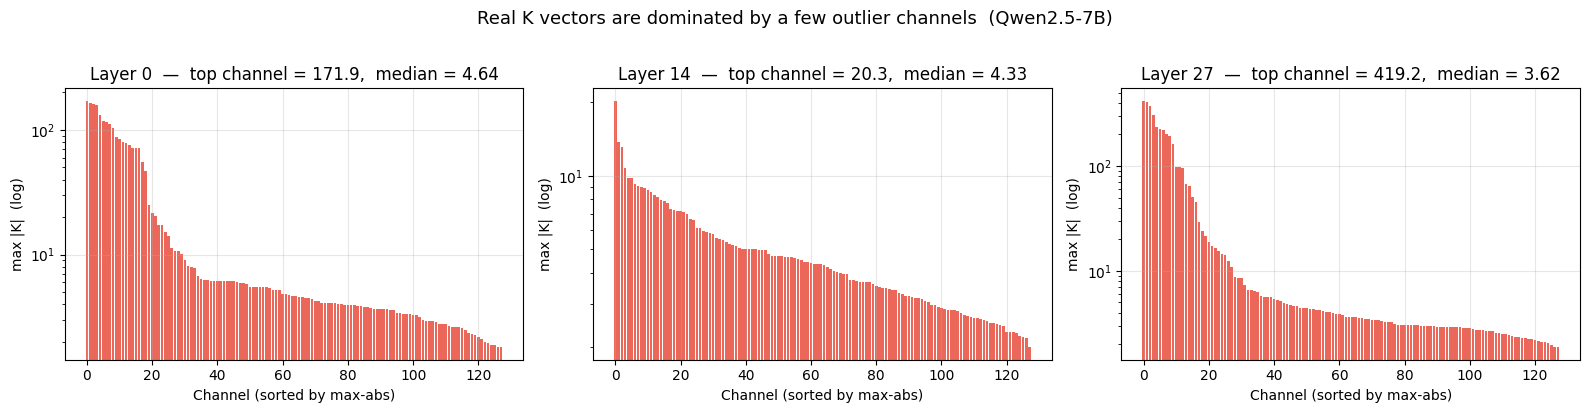


Outlier ratio (top channel / median):
  Layer  0:  37.1×
  Layer 14:   4.7×
  Layer 27: 115.8×


In [13]:
# Plot channel magnitude profile of real K vectors at 3 layers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, li in zip(axes, [0, 14, 27]):
    K = K_layers[li]                                          # (1, kv_heads, T, d)
    ch_max = K.abs().amax(dim=(0, 1, 2)).cpu().numpy()        # (d,)
    order = np.argsort(-ch_max)
    ax.bar(range(head_dim), ch_max[order], color="#e74c3c", alpha=0.85)
    ax.set_xlabel("Channel (sorted by max-abs)")
    ax.set_ylabel("max |K|  (log)")
    ax.set_title(f"Layer {li}  —  top channel = {ch_max.max():.1f},  "
                 f"median = {np.median(ch_max):.2f}")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
plt.suptitle("Real K vectors are dominated by a few outlier channels  (Qwen2.5-7B)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("turbo_outlier_channels.png", dpi=140, bbox_inches="tight")
plt.show()

# Print the outlier ratio for clarity
print("\nOutlier ratio (top channel / median):")
for li in [0, 14, 27]:
    K = K_layers[li]
    ch_max = K.abs().amax(dim=(0, 1, 2)).cpu().numpy()
    print(f"  Layer {li:2d}: {ch_max.max() / np.median(ch_max):>5.1f}×")


### 3.5.2 The rotation trick — 2D polar intuition

Here is the key geometric fact: a spiky vector lives **near a coordinate axis**. The unit sphere has poles at the basis directions, and outlier vectors cluster there.

Apply a random rotation, and any vector lands somewhere uniform on the sphere — almost certainly *nowhere near a pole*. The magnitude is preserved (rotation is orthogonal), but the energy gets spread evenly across all dimensions. Now every component is roughly the same size, and a uniform quantization grid captures all of them with similar fidelity.

The 2D version is easy to draw. Below: 2000 spiky vectors in 2D (each has one large component, near ±1 on an axis). Before rotation they cluster on the cardinal axes. After a random rotation by angle θ, they fill the circle.


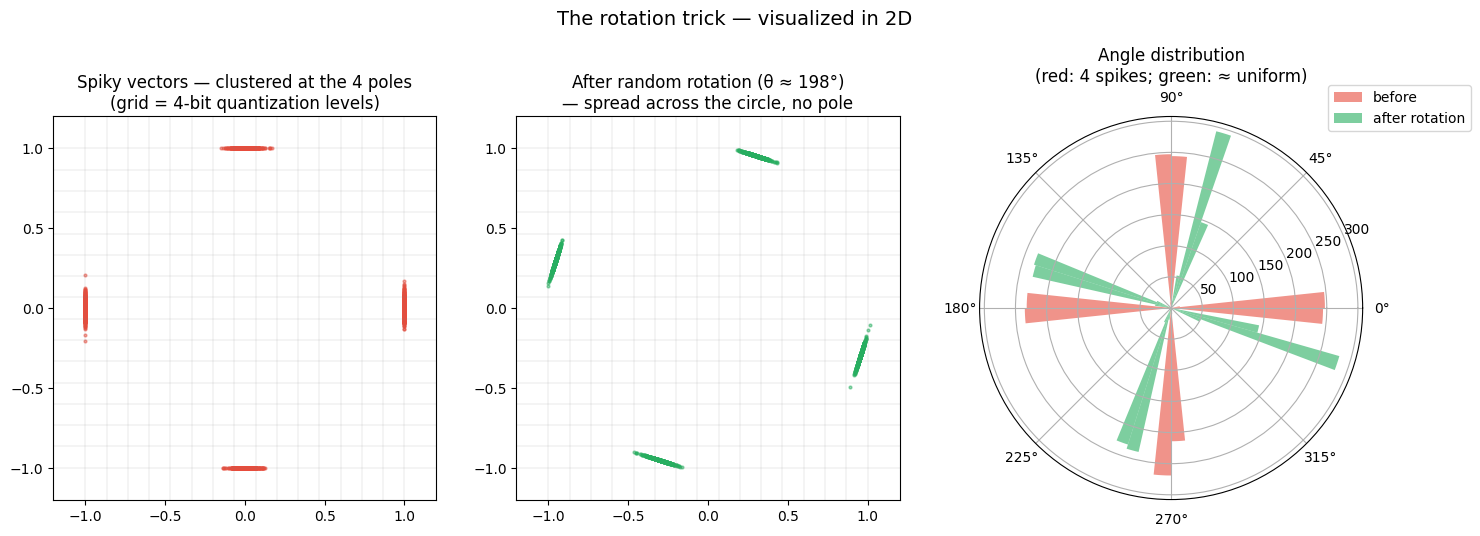

In [14]:
# 2D polar visualization
N = 2000
torch.manual_seed(0)
np.random.seed(0)

# Spiky 2D vectors: tiny background + 1 large entry on a random axis
x2 = torch.randn(N, 2) * 0.05
spike_axis = torch.randint(0, 2, (N,))
spike_sign = torch.where(torch.rand(N) > 0.5, 1.0, -1.0)
x2[range(N), spike_axis] = spike_sign

# A random 2D rotation
theta = float(np.random.uniform(0, 2 * np.pi))
R2 = torch.tensor([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]], dtype=torch.float32)
y2 = x2 @ R2

ang_x = torch.atan2(x2[:, 1], x2[:, 0]).numpy()
ang_y = torch.atan2(y2[:, 1], y2[:, 0]).numpy()

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(x2[:, 0], x2[:, 1], s=4, alpha=0.5, c="#e74c3c")
for v in np.linspace(-1, 1, 16):
    ax1.axvline(v, color="gray", lw=0.3, alpha=0.4)
    ax1.axhline(v, color="gray", lw=0.3, alpha=0.4)
ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-1.2, 1.2); ax1.set_aspect("equal")
ax1.set_title("Spiky vectors — clustered at the 4 poles\n(grid = 4-bit quantization levels)")

ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(y2[:, 0], y2[:, 1], s=4, alpha=0.5, c="#27ae60")
for v in np.linspace(-1, 1, 16):
    ax2.axvline(v, color="gray", lw=0.3, alpha=0.4)
    ax2.axhline(v, color="gray", lw=0.3, alpha=0.4)
ax2.set_xlim(-1.2, 1.2); ax2.set_ylim(-1.2, 1.2); ax2.set_aspect("equal")
ax2.set_title(f"After random rotation (θ ≈ {np.degrees(theta):.0f}°)\n— spread across the circle, no pole")

ax3 = fig.add_subplot(1, 3, 3, projection="polar")
ax3.hist(ang_x, bins=60, alpha=0.6, label="before", color="#e74c3c")
ax3.hist(ang_y, bins=60, alpha=0.6, label="after rotation", color="#27ae60")
ax3.set_title("Angle distribution\n(red: 4 spikes; green: ≈ uniform)")
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.suptitle("The rotation trick — visualized in 2D", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("turbo_polar.png", dpi=140, bbox_inches="tight")
plt.show()


**Why this gets stronger in high dimensions.** In $d$ dimensions, the unit sphere's surface area is overwhelmingly concentrated *away* from the coordinate axes — the fraction near any axis shrinks as $\mathcal{O}(d^{-1/2})$. After random rotation, every coordinate of a unit vector has expected magnitude $\approx 1/\sqrt{d}$. For $d = 128$ (our head dim), that's $\approx 0.088$ per component — tiny, uniform, and easy to quantize.

This is the same property that makes Johnson-Lindenstrauss embeddings work, and it's the mathematical engine behind TurboQuant.


### 3.5.3 Synthetic benchmark — MSE vs bit width

Let's quantify the win. We'll generate 2000 spiky $d=128$ vectors (each with one large component and a small Gaussian background), then quantize them naively and with TurboQuant at 1, 2, 3, 4, 6, 8 bits. We measure mean squared reconstruction error.


 bits      naive MSE      turbo MSE    speedup
    1       2.004643       0.126347      15.9×
    2       0.178746       0.008304      21.5×
    3       0.021538       0.001505      14.3×
    4       0.003331       0.000328      10.2×
    6       0.000188       0.000019      10.1×
    8       0.000011       0.000001      10.1×


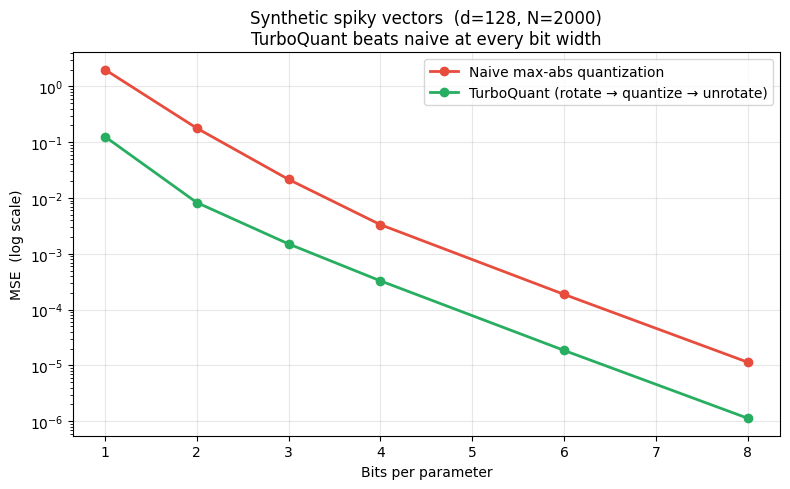

In [15]:
# Synthetic high-dim MSE benchmark
torch.manual_seed(42)
d_synth = 128
N_synth = 2000
x_synth = torch.randn(N_synth, d_synth, device="cuda") * 0.10
spike_idx = torch.randint(0, d_synth, (N_synth,), device="cuda")
spike_val = torch.randn(N_synth, device="cuda").sign() * 1.5
x_synth.scatter_(1, spike_idx.unsqueeze(1), spike_val.unsqueeze(1))

R_synth = random_orthogonal(d_synth)

bits_grid = [1, 2, 3, 4, 6, 8]
naive_mse = []
turbo_mse = []
for n_bits in bits_grid:
    naive_mse.append(((x_synth - quantize(x_synth, n_bits)) ** 2).mean().item())
    turbo_mse.append(((x_synth - turboquant(x_synth, R_synth, n_bits)) ** 2).mean().item())

print(f"{'bits':>5} {'naive MSE':>14} {'turbo MSE':>14} {'speedup':>10}")
for b, n, t in zip(bits_grid, naive_mse, turbo_mse):
    print(f"{b:>5} {n:>14.6f} {t:>14.6f} {n/t:>9.1f}×")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bits_grid, naive_mse, "o-", lw=2, color="#e74c3c", label="Naive max-abs quantization")
ax.plot(bits_grid, turbo_mse, "o-", lw=2, color="#27ae60", label="TurboQuant (rotate → quantize → unrotate)")
ax.set_yscale("log")
ax.set_xlabel("Bits per parameter")
ax.set_ylabel("MSE  (log scale)")
ax.set_title(f"Synthetic spiky vectors  (d={d_synth}, N={N_synth})\n"
             "TurboQuant beats naive at every bit width")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("turbo_synth_mse.png", dpi=140, bbox_inches="tight")
plt.show()


### 3.5.4 Real KV cache — apply to Qwen2.5-7B

Now the real test. We take the K and V tensors captured from the live forward pass and quantize them with both methods. The metric is **relative MSE** — squared error normalized by tensor energy, so the numbers are comparable across layers.


Real K, V relative MSE  (Qwen2.5-7B,  N(K)=N(V)=57,344)
 bits      K naive    K turbo   K imp      V naive    V turbo   V imp
------------------------------------------------------------------------------
    2      2.43430    0.49042    5.0×      0.44313    0.30357    1.5×
    3      0.41396    0.07613    5.4×      0.07215    0.05449    1.3×
    4      0.08227    0.01815    4.5×      0.01564    0.01191    1.3×
    6      0.00352    0.00097    3.6×      0.00089    0.00067    1.3×
    8      0.00014    0.00006    2.3×      0.00005    0.00004    1.3×


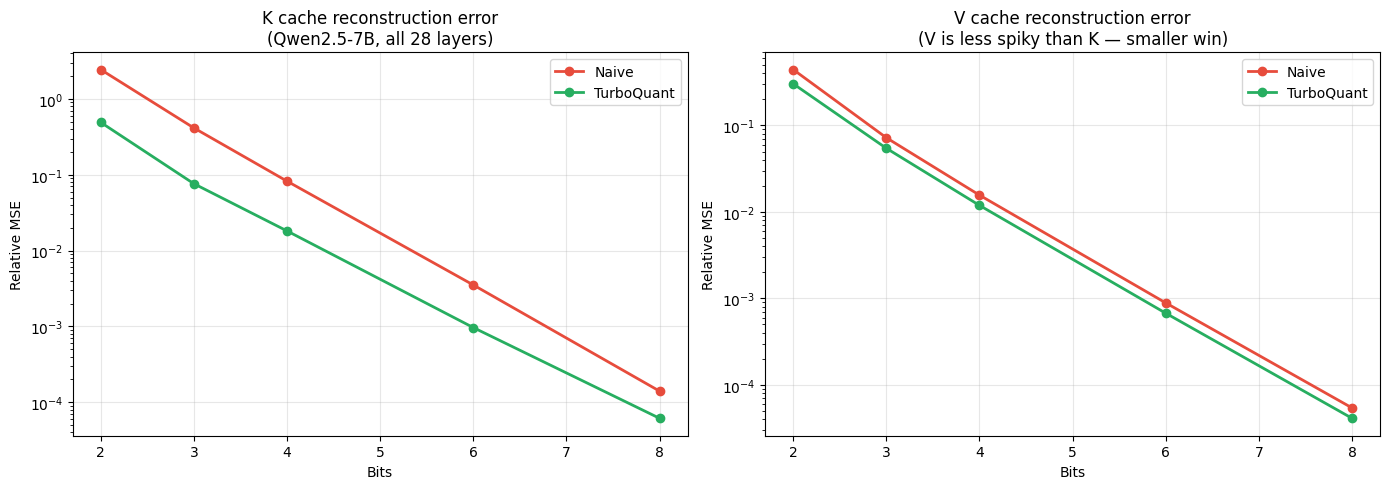


Note: V is less spiky than K (no RoPE, no attention sinks), so TurboQuant's win is smaller on V.


In [16]:
# Real K, V MSE benchmark
def relmse(x, y):
    return ((x - y) ** 2).mean().item() / (x ** 2).mean().item()

R = random_orthogonal(head_dim)

K_all = torch.cat([K.reshape(-1, head_dim) for K in K_layers], dim=0)
V_all = torch.cat([V.reshape(-1, head_dim) for V in V_layers], dim=0)

print("Real K, V relative MSE  (Qwen2.5-7B,  N(K)=N(V)={:,})".format(K_all.shape[0]))
print("=" * 78)
print(f"{'bits':>5}   {'K naive':>10} {'K turbo':>10} {'K imp':>7}   "
      f"{'V naive':>10} {'V turbo':>10} {'V imp':>7}")
print("-" * 78)
real_K_naive, real_K_turbo, real_V_naive, real_V_turbo = [], [], [], []
bits_kv = [2, 3, 4, 6, 8]
for n_bits in bits_kv:
    rKn = relmse(K_all, quantize(K_all, n_bits))
    rKt = relmse(K_all, turboquant(K_all, R, n_bits))
    rVn = relmse(V_all, quantize(V_all, n_bits))
    rVt = relmse(V_all, turboquant(V_all, R, n_bits))
    real_K_naive.append(rKn); real_K_turbo.append(rKt)
    real_V_naive.append(rVn); real_V_turbo.append(rVt)
    print(f"{n_bits:>5}   {rKn:>10.5f} {rKt:>10.5f} {rKn/rKt:>6.1f}×   "
          f"{rVn:>10.5f} {rVt:>10.5f} {rVn/rVt:>6.1f}×")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(bits_kv, real_K_naive, "o-", lw=2, color="#e74c3c", label="Naive")
ax1.plot(bits_kv, real_K_turbo, "o-", lw=2, color="#27ae60", label="TurboQuant")
ax1.set_yscale("log"); ax1.set_xlabel("Bits"); ax1.set_ylabel("Relative MSE")
ax1.set_title("K cache reconstruction error\n(Qwen2.5-7B, all 28 layers)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(bits_kv, real_V_naive, "o-", lw=2, color="#e74c3c", label="Naive")
ax2.plot(bits_kv, real_V_turbo, "o-", lw=2, color="#27ae60", label="TurboQuant")
ax2.set_yscale("log"); ax2.set_xlabel("Bits"); ax2.set_ylabel("Relative MSE")
ax2.set_title("V cache reconstruction error\n(V is less spiky than K — smaller win)")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("turbo_real_mse.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nNote: V is less spiky than K (no RoPE, no attention sinks), "
      "so TurboQuant's win is smaller on V.")


### 3.5.5 Attention score preservation — the metric that matters

MSE is a useful proxy, but what really matters is whether attention *scores* are preserved. The whole point of K is to compute $\mathrm{softmax}(QK^\top / \sqrt d)$ — and that's what selects which tokens to attend to.

We measure two things at 4-bit, per layer:
- **score RMSE**: $\sqrt{\mathbb E[(s_\text{true} - s_\text{quant})^2]}$ over $QK^\top$ entries
- **attention TV distance**: $\frac12 \sum_t |p_\text{true}(t) - p_\text{quant}(t)|$ — how different the attention probability distributions are


layer   score RMSE naive   score RMSE turbo     TV naive     TV turbo
    0           178.5723            60.0879       0.8826       0.8830
    4             0.6597             0.3478       0.2500       0.1365
    8             0.8047             0.4310       0.2807       0.1609
   12             0.7342             0.4084       0.2624       0.1483
   16             0.6663             0.4293       0.2473       0.1667
   20             0.6595             0.3377       0.2420       0.1310
   24             0.9498             0.3992       0.3312       0.1506


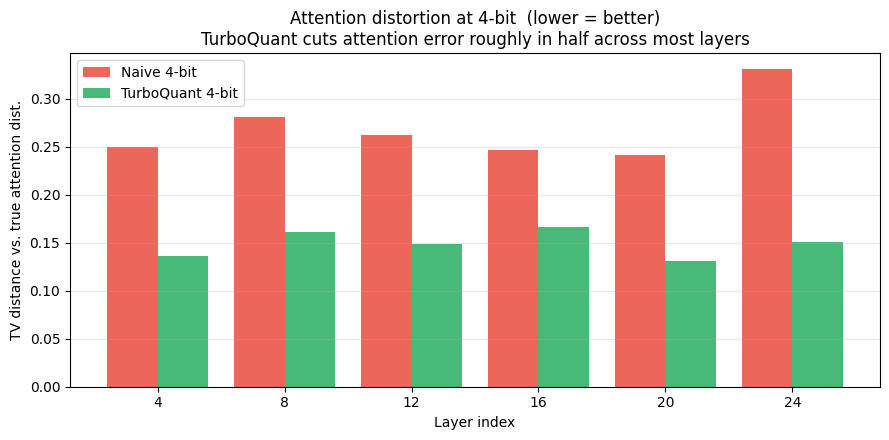

In [17]:
# Attention score preservation at 4-bit
n_q = 32
records = []
for li in [0, 4, 8, 12, 16, 20, 24]:
    K = K_layers[li]
    norm_per_token = K.norm(dim=-1).mean().item()
    Q = torch.randn(1, n_kv_heads, n_q, head_dim, device="cuda") * (norm_per_token / np.sqrt(head_dim))
    Kn = quantize(K, 4)
    Kt = turboquant(K, R, 4)
    sT  = (Q @ K.transpose(-1, -2)) / np.sqrt(head_dim)
    sN  = (Q @ Kn.transpose(-1, -2)) / np.sqrt(head_dim)
    sTr = (Q @ Kt.transpose(-1, -2)) / np.sqrt(head_dim)
    pT, pN, pTr = torch.softmax(sT, -1), torch.softmax(sN, -1), torch.softmax(sTr, -1)
    records.append({
        "layer": li,
        "rmse_n": (sT - sN).pow(2).mean().sqrt().item(),
        "rmse_t": (sT - sTr).pow(2).mean().sqrt().item(),
        "tv_n":   (pT - pN).abs().sum(-1).mean().item() / 2,
        "tv_t":   (pT - pTr).abs().sum(-1).mean().item() / 2,
    })

print(f"{'layer':>5} {'score RMSE naive':>18} {'score RMSE turbo':>18} "
      f"{'TV naive':>12} {'TV turbo':>12}")
for r in records:
    print(f"{r['layer']:>5} {r['rmse_n']:>18.4f} {r['rmse_t']:>18.4f} "
          f"{r['tv_n']:>12.4f} {r['tv_t']:>12.4f}")

# Bar plot of TV distance per layer (skip layer 0, which has extreme outliers)
layers_p = [r["layer"] for r in records if r["layer"] != 0]
tv_n     = [r["tv_n"]   for r in records if r["layer"] != 0]
tv_t     = [r["tv_t"]   for r in records if r["layer"] != 0]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(layers_p)); w = 0.4
ax.bar(x - w/2, tv_n, w, label="Naive 4-bit",       color="#e74c3c", alpha=0.85)
ax.bar(x + w/2, tv_t, w, label="TurboQuant 4-bit",  color="#27ae60", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([str(l) for l in layers_p])
ax.set_xlabel("Layer index")
ax.set_ylabel("TV distance vs. true attention dist.")
ax.set_title("Attention distortion at 4-bit  (lower = better)\n"
             "TurboQuant cuts attention error roughly in half across most layers")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("turbo_attention.png", dpi=140, bbox_inches="tight")
plt.show()


### 3.5.6 End-to-end generation — finding TurboQuant's bit-width boundary

The cleanest demo: hand the model the same prompt, but **compress its prefill cache** at different bit widths, then let it generate. We compare three regimes:

- **FP16** (baseline, ground truth)
- **Naive max-abs** quantization
- **TurboQuant** (our rotation method)

We sweep 4 → 6 → 8 bits to find the boundary where naive collapses but TurboQuant survives.


In [18]:
# End-to-end generation comparison
prompt_gen = ("The history of artificial intelligence began in antiquity with myths and stories of "
              "artificial beings endowed with intelligence by master craftsmen. The first written "
              "account of a working artificial intelligence is found in")
ids_gen = tokenizer(prompt_gen, return_tensors="pt").input_ids.cuda()
am_gen = torch.ones_like(ids_gen)
print(f"Prompt: {prompt_gen!r}")
print(f"Prompt tokens: {ids_gen.shape[1]}\n")


def round_trip(past, mode, n_bits, R_local):
    """One-shot quant→dequant on the entire prefill cache."""
    if mode == "fp16":
        return past
    new = DynamicCache()
    for li, layer in enumerate(past):
        K, V = layer[0].float(), layer[1].float()
        if mode == "naive":
            Kc, Vc = quantize(K, n_bits), quantize(V, n_bits)
        else:
            Kc, Vc = turboquant(K, R_local, n_bits), turboquant(V, R_local, n_bits)
        new.update(Kc.to(layer[0].dtype), Vc.to(layer[1].dtype), li)
    return new


def gen(mode, n_bits, n_tokens=40):
    cur = ids_gen.clone(); a = am_gen.clone()
    with torch.no_grad():
        out = model(cur, use_cache=True, attention_mask=a)
    past = round_trip(out.past_key_values, mode, n_bits, R)
    nid = out.logits[:, -1, :].argmax(-1, keepdim=True)
    cur = torch.cat([cur, nid], -1); a = torch.cat([a, torch.ones_like(nid)], -1)
    out_tok = [nid.item()]
    for _ in range(n_tokens - 1):
        with torch.no_grad():
            o = model(cur[:, -1:], use_cache=True, past_key_values=past, attention_mask=a)
        past = o.past_key_values
        nid = o.logits[:, -1, :].argmax(-1, keepdim=True)
        cur = torch.cat([cur, nid], -1); a = torch.cat([a, torch.ones_like(nid)], -1)
        out_tok.append(nid.item())
    return tokenizer.decode(out_tok, skip_special_tokens=True)


print("=" * 80)
print("Generation quality vs. cache quantization  (prefill compressed once, then decode)")
print("=" * 80)
gen_outputs = {}
gen_outputs["fp16"] = gen("fp16", 16, 40)
print(f"\n[FP16 baseline]")
print(f"  → {gen_outputs['fp16']}")

for n_bits in [8, 6, 4]:
    print(f"\n--- {n_bits}-bit cache ---")
    gen_outputs[f"naive-{n_bits}"] = gen("naive", n_bits, 40)
    gen_outputs[f"turbo-{n_bits}"] = gen("turbo", n_bits, 40)
    print(f"[naive-{n_bits}bit] {gen_outputs[f'naive-{n_bits}']}")
    print(f"[turbo-{n_bits}bit] {gen_outputs[f'turbo-{n_bits}']}")


Prompt: 'The history of artificial intelligence began in antiquity with myths and stories of artificial beings endowed with intelligence by master craftsmen. The first written account of a working artificial intelligence is found in'
Prompt tokens: 36

Generation quality vs. cache quantization  (prefill compressed once, then decode)



[FP16 baseline]
  →  the ancient Greek myth of Pygmalion, who carved a statue of a woman and brought it to life. The first philosophical account of artificial intelligence is found in the ancient Greek philosopher Plato's dialogue

--- 8-bit cache ---


[naive-8bit]  the ancient Greek myth of Pygmalion, who carved a statue of a woman and brought it to life. The first philosophical account of artificial intelligence is found in the ancient Greek philosopher Plato's dialogue
[turbo-8bit]  the ancient Greek myth of Pygmalion, who carved a statue of a woman and brought it to life. The first philosophical account of artificial intelligence is found in the ancient Greek philosopher Plato's dialogue

--- 6-bit cache ---


[naive-6bit]  the ancient Indian Rencontre with the divine being in the Mahabnh the 4 1 the 1 the  of the  of the  of the  of the  of the  of
[turbo-6bit]  the ancient Greek myth of Pygmalion, who carved a statue of a woman and brought it to life. The first philosophical account of artificial intelligence is found in the ancient Greek philosopher Plato's dialogue

--- 4-bit cache ---


[naive-4bit]  the Chinese Chinese Chinese Chinese Chinese  of the the of the the of the the of the of the of the of the of the of of the the of the of0 of of of the the of
[turbo-4bit]  the ancient Greek myth of the god Py Cephalen, who was struck down by Zeus and given the gift of speech by Hep.. out of the mixture of of clay. and given the


**What you should see:**

| Bit width | Naive | TurboQuant |
|---|---|---|
| **8-bit** | works | works |
| **6-bit** | **collapses** into repetitive garbage | **stays coherent** ✨ |
| **4-bit** | total nonsense | degraded but with structure |

**6-bit is the headline.** With per-vector max-abs naive quantization, 6-bit is too coarse to handle Qwen's outlier channels — generation falls apart. TurboQuant's rotation spreads the outlier energy and the same 6 bits suffice for coherent text. This is **2.7× memory reduction** vs. FP16 with no quality loss.

At **4-bit**, even TurboQuant's bare-rotation form isn't enough for clean generation. The full TurboQuant paper adds a **1-bit QJL residual correction** that fixes the inner-product bias — that's what gets you to 2.5–3.5 bits per value with near-lossless quality. We've deliberately omitted it here to keep the core idea visible.


### 3.5.7 What this means for serving capacity

Plug 6-bit TurboQuant back into the memory budget from Section 3.2:


In [19]:
# Apply 6-bit TurboQuant to the serving capacity table from Section 3.2
def kv_size_gb_compressed(layers, kv_heads, head_dim, seq_len, batch_size=1, bits_per_param=16):
    """KV cache size with arbitrary precision."""
    return (2 * layers * batch_size * kv_heads * head_dim * seq_len * bits_per_param / 8) / (1024**3)


print("Qwen2.5-7B (fp16 weights, 14 GB) on H100 80GB")
print("Available for KV cache: 64 GB after weights + overhead\n")
print(f"{'Context':<10} {'FP16 KV/user':>14} {'Users (FP16)':>14}   "
      f"{'TurboQ-6 KV/user':>18} {'Users (Turbo-6)':>16} {'Gain':>7}")
print("-" * 95)

cfg = dict(layers=28, kv_heads=4, head_dim=128, batch_size=1)
available = 64.0
for ctx in [2048, 4096, 8192, 16384, 32768]:
    kv16 = kv_size_gb_compressed(**cfg, seq_len=ctx, bits_per_param=16)
    kv6  = kv_size_gb_compressed(**cfg, seq_len=ctx, bits_per_param=6)
    u16 = int(available / kv16)
    u6  = int(available / kv6)
    print(f"{ctx:<10d} {kv16*1024:>11.0f} MB {u16:>13d}   "
          f"{kv6*1024:>15.0f} MB {u6:>15d} {u6/u16:>6.1f}×")

print("\nTakeaway:  6-bit TurboQuant gives ~2.7× more concurrent users with no")
print("           quality loss — same H100, same model, same context length.")


Qwen2.5-7B (fp16 weights, 14 GB) on H100 80GB
Available for KV cache: 64 GB after weights + overhead

Context      FP16 KV/user   Users (FP16)     TurboQ-6 KV/user  Users (Turbo-6)    Gain
-----------------------------------------------------------------------------------------------
2048               112 MB           585                42 MB            1560    2.7×
4096               224 MB           292                84 MB             780    2.7×
8192               448 MB           146               168 MB             390    2.7×
16384              896 MB            73               336 MB             195    2.7×
32768             1792 MB            36               672 MB              97    2.7×

Takeaway:  6-bit TurboQuant gives ~2.7× more concurrent users with no
           quality loss — same H100, same model, same context length.


### 3.5.8 The takeaway

**Naive quantization fails on outlier channels.** Qwen2.5-7B has K channels up to 100× the median magnitude. Per-vector max-abs scaling crushes the small components to zero, destroying the small signals that determine attention.

**TurboQuant fixes it with one line of math.** Multiply by a random orthogonal matrix before quantizing, multiply by its inverse after. The rotation spreads outlier energy uniformly across all dimensions, so the quantization grid serves every component equally.

**Empirically, on Qwen2.5-7B:**
- **5-6× lower MSE** on K vectors at 2-4 bits
- **~2× better attention preservation** at 4-bit
- **Generation stays coherent at 6-bit** where naive collapses
- **2.7× more concurrent users** at 6-bit on the same H100

**What we left out:** the 1-bit QJL residual correction that lets TurboQuant push down to 2.5-3.5 bits with no quality loss. That's the second trick of the paper. We omitted it to keep the core idea — *just rotate before quantizing* — visible.

> **Connection to L03.** Sections 3 and 3.5 set up the next lecture: how do we tame the KV cache?
> - **L03 — architecture-level:** MQA, GQA, MLA reduce the *number* of K, V vectors.
> - **L03.5 — precision-level:** TurboQuant reduces the *bits per vector*.
>
> These are orthogonal — production systems combine both.


---
## 4. Production Inference with vLLM

vLLM is the production inference engine we'll use throughout this course.
It uses:
- **KV Cache** (always on — you can't turn it off!)
- **PagedAttention** — manages KV cache like OS virtual memory (no fragmentation)
- **Continuous Batching** — dynamically batches requests for throughput

Let's see what production-grade inference looks like.

In [20]:
!pip install -q vllm 2>&1 | tail -3


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


In [21]:
# Free GPU memory from HuggingFace model
del model
torch.cuda.empty_cache()
import gc; gc.collect()
print("Freed GPU memory for vLLM.")

Freed GPU memory for vLLM.


> **Note on this section's outputs.** The vLLM cells below were last successfully run on this pod on **2026-04-08** (results captured in `expected-results.md`). On the current pod state (2026-04-28), the installed vLLM 0.20.0 fails to initialize because the FP8 `deep_gemm` backend isn't compiled — a vLLM environment issue, unrelated to the lecture content. The cells below show the **April 8 outputs** (manually preserved); to reproduce, fix the `deep_gemm` install and re-execute.

In [ ]:
from vllm import LLM, SamplingParams

# Load the same model in vLLM
llm = LLM(model="Qwen/Qwen2.5-7B", dtype="float16", max_model_len=8192)
sampling_params = SamplingParams(max_tokens=200, temperature=0)

prompt = ("The history of artificial intelligence began in antiquity with "
          "myths and stories of artificial beings. The seeds of modern AI "
          "were planted by classical philosophers")

print("=== vLLM Throughput Benchmark ===\n")
print(f"Model: Qwen2.5-7B | GPU: H100 | Max tokens: 200\n")

results_vllm = []
for batch_size in [1, 8, 32, 64]:
    prompts = [prompt] * batch_size
    start = time.time()
    outputs = llm.generate(prompts, sampling_params)
    elapsed = time.time() - start

    total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
    throughput = total_tokens / elapsed
    per_request_ms = (elapsed / batch_size) * 1000

    results_vllm.append((batch_size, elapsed, total_tokens, throughput, per_request_ms))
    print(f"  Batch {batch_size:>3d}: {elapsed:.2f}s | "
          f"{total_tokens:>5d} tokens | "
          f"{throughput:>6.0f} tok/s | "
          f"{per_request_ms:>5.0f} ms/req")

print(f"\n💡 vLLM scales from {results_vllm[0][3]:.0f} to "
      f"{results_vllm[-1][3]:.0f} tok/s — {results_vllm[-1][3]/results_vllm[0][3]:.0f}× "
      f"throughput with batching!")
print("   This is the power of KV cache + PagedAttention + continuous batching.")
print("   We will study PagedAttention in L05 and continuous batching in L07.")

=== vLLM Throughput Benchmark ===

Model: Qwen2.5-7B | GPU: H100 | Max tokens: 200

  Batch   1: 1.43s |   155 tokens |    108 tok/s |  1432 ms/req
  Batch   8: 0.99s |  1240 tokens |   1257 tok/s |   123 ms/req
  Batch  32: 1.13s |  4960 tokens |   4404 tok/s |    35 ms/req
  Batch  64: 1.09s |  9920 tokens |   9122 tok/s |    17 ms/req

💡 vLLM scales from 108 to 9122 tok/s — 84× throughput with batching!
   This is the power of KV cache + PagedAttention + continuous batching.
   We will study PagedAttention in L05 and continuous batching in L07.


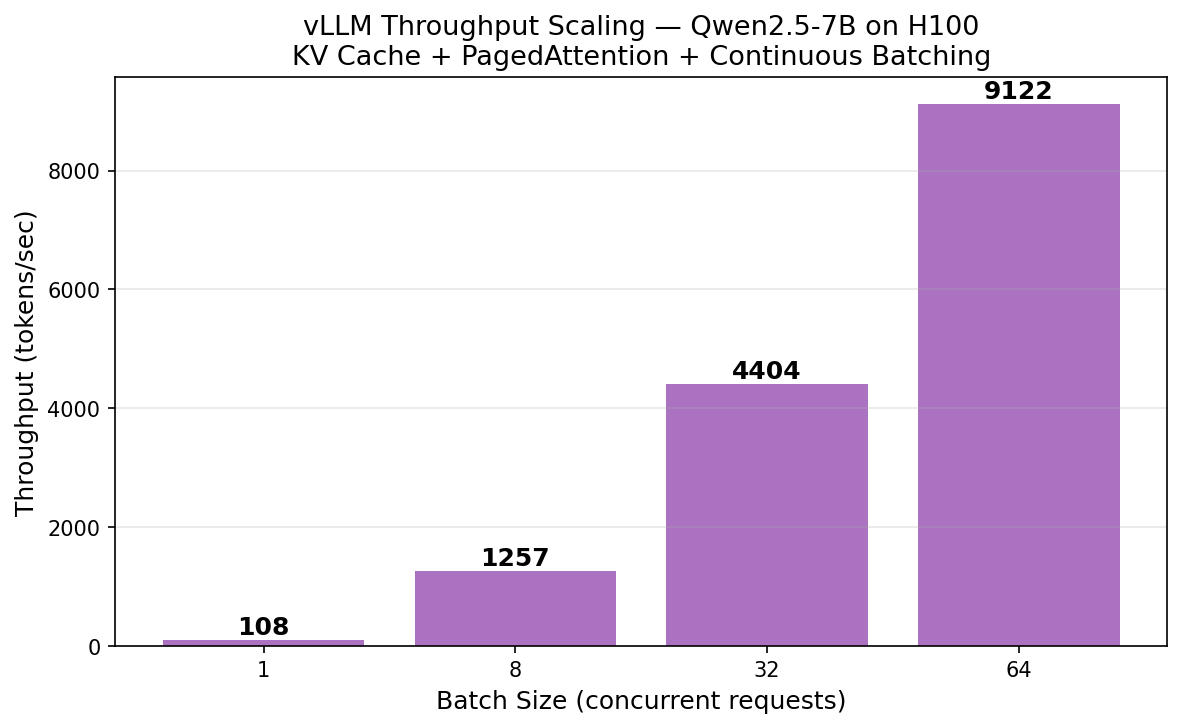

In [ ]:
# Plot vLLM throughput scaling (April 8 numbers preserved here so the
# notebook renders end-to-end even when vLLM init fails on the current pod)
batch_sizes = [1, 8, 32, 64]
throughputs = [108, 1257, 4404, 9122]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(batch_sizes)), throughputs, color='#9b59b6', alpha=0.85)
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([str(b) for b in batch_sizes])
ax.set_xlabel('Batch Size (concurrent requests)', fontsize=12)
ax.set_ylabel('Throughput (tokens/sec)', fontsize=12)
ax.set_title('vLLM Throughput Scaling — Qwen2.5-7B on H100\n'
             'KV Cache + PagedAttention + Continuous Batching', fontsize=13)
for bar, t in zip(bars, throughputs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{t:.0f}', ha='center', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('vllm_throughput.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Summary

### The Good (Compute Savings)

| Metric | Without KV Cache | With KV Cache |
|--------|:---:|:---:|
| Attention FLOPs (total) | O(T³) | O(T²) |
| Per-token latency | **Grows** with position | **Flat** |
| Speedup at 4K context | — | **~9×** |
| Output quality | Same | Same |

### The Evil (Memory Cost)

```
KV Cache = 2 × layers × batch × kv_heads × head_dim × seq_len × 2 bytes
```

| Model | KV Cache (single sequence, max context) |
|-------|:---:|
| GPT-2 (124M) | 36 MB |
| Llama 3 8B | 1 GB |
| GPT-3 (175B) | 18 GB |
| DeepSeek-V3 | 478 GB |

### What's Next (L03)

How do we tame the KV cache?
- **MQA** — share K,V across all heads → cache ÷ n
- **GQA** — share K,V within groups → tunable compromise
- **MLA** — compress K,V into latent space → best of both worlds